# Setup Project

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content/drive/My Drive/Colab Notebooks/American Football/Resources


In [ ]:
!pip uninstall opencv-python opencv-python-headless opencv-contrib-python -y
!pip install -q ultralytics roboflow inference supervision inference-sdk opencv-contrib-python

Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-python-headless 4.11.0.86
Uninstalling opencv-python-headless-4.11.0.86:
  Successfully uninstalled opencv-python-headless-4.11.0.86
Found existing installation: opencv-contrib-python 4.11.0.86
Uninstalling opencv-contrib-python-4.11.0.86:
  Successfully uninstalled opencv-contrib-python-4.11.0.86
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.2/915.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from inference import get_model
import supervision as sv
from google.colab.patches import cv2_imshow
from tqdm.notebook import tqdm
import numpy as np
from roboflow import Roboflow
import cv2

# load a pre-trained yolov8n model
player_model = get_model(model_id="football-players-zm06l/15", api_key="KiJqNqE8Kvgwg8Ur91US")
keypoint_model = get_model(model_id="football-field-key-points/9", api_key="KiJqNqE8Kvgwg8Ur91US")
snap_clf_model = get_model(model_id="snapdetection/5", api_key="KiJqNqE8Kvgwg8Ur91US")
helmet_model = get_model(model_id="sportslocationtracking_helmets-2bdmq/2", api_key="KiJqNqE8Kvgwg8Ur91US")

# Constants
Contant variables used in the notebook

In [ ]:
# KEYPOINT INFORMATION

KEYPOINT_NAMES = ['goalline', 'goalline-bottom', '10', '10-top-hash',
                  '10-bottom-hash', '10-bottom', '20', '20-top-hash',
                  '20-bottom-hash', '20-bottom', '30', '30-top-hash',
                  '30-bottom-hash', '30-bottom', '40', '40-top-hash',
                  '40-bottom-hash', '40-bottom', '50', '50-top-hash',
                  '50-bottom', 'back-endzone', 'endzone-bottom',
                  '50-bottom-hash', '50-top-sl', '50-bottom-sl',
                  '40-top-sl', '40-bottom-sl', '30-top-sl', '30-bottom-sl',
                  '20-top-sl', '20-bottom-sl', '10-top-sl', '10-bottom-sl',
                  'FG-POST', '5-top-sl', '5-top-hash', '5-bottom-hash',
                  '5-bottom-sl']





# DETECTION INFORMATION

SKILL_ID = 4
LB_ID = 2
DB_ID = 1
C_ID = 0
QB_ID = 3

PLAYER_COLOR_DICT = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255),
    3: (255, 255, 0),
    4: (255, 0, 255),
}

PLAYER_NAME_DICT = {
    0: "C",
    1: "DB",
    2: "LB",
    3: "QB",
    4: "SK",
}





# FIELD LAYOUT

TOP_SL = 0
TOP_NUM = 42
TOP_HASH = 70
BOTTOM_HASH = 90
BOTTOM_NUM = 118
BOTTOM_SL = 160

FG_POST = 80
BACK_ENDZONE = 0
GOALLINE = 30
FIVE = 45
TEN = 60
TWENTY = 90
THIRTY = 120
FORTY = 150
FIFTY = 180

X_PAD = 10
Y_PAD = 10

FIELD_WIDTH = 160
FIELD_HEIGHT = 360

SCALE = 3

def fieldTuple(x, y):
  return ((x * SCALE) + X_PAD, (y * SCALE) + Y_PAD)

FIELD_MAP = {'10-top-sl': fieldTuple(TOP_SL, TEN), '10': fieldTuple(TOP_NUM, TEN), '10-top-hash': fieldTuple(TOP_HASH, TEN),
            '10-bottom-hash': fieldTuple(BOTTOM_HASH, TEN), '10-bottom': fieldTuple(BOTTOM_NUM, TEN), '10-bottom-sl': fieldTuple(BOTTOM_SL, TEN),

            '20-top-sl': fieldTuple(TOP_SL, TWENTY), '20': fieldTuple(TOP_NUM, TWENTY), '20-top-hash': fieldTuple(TOP_HASH, TWENTY),
            '20-bottom-hash': fieldTuple(BOTTOM_HASH, TWENTY), '20-bottom': fieldTuple(BOTTOM_NUM, TWENTY), '20-bottom-sl': fieldTuple(BOTTOM_SL, TWENTY),

            '30-top-sl': fieldTuple(TOP_SL, THIRTY), '30': fieldTuple(TOP_NUM, THIRTY), '30-top-hash': fieldTuple(TOP_HASH, THIRTY),
            '30-bottom-hash': fieldTuple(BOTTOM_HASH, THIRTY), '30-bottom': fieldTuple(BOTTOM_NUM, THIRTY), '30-bottom-sl': fieldTuple(BOTTOM_SL, THIRTY),

            '40-top-sl': fieldTuple(TOP_SL, FORTY), '40': fieldTuple(TOP_NUM, FORTY), '40-top-hash': fieldTuple(TOP_HASH, FORTY),
            '40-bottom-hash': fieldTuple(BOTTOM_HASH, FORTY), '40-bottom': fieldTuple(BOTTOM_NUM, FORTY), '40-bottom-sl': fieldTuple(BOTTOM_SL, FORTY),

            '50-top-sl': fieldTuple(TOP_SL, FIFTY), '50': fieldTuple(TOP_NUM, FIFTY), '50-top-hash': fieldTuple(TOP_HASH, FIFTY),
            '50-bottom-hash': fieldTuple(BOTTOM_HASH, FIFTY), '50-bottom': fieldTuple(BOTTOM_NUM, FIFTY), '50-bottom-sl': fieldTuple(BOTTOM_SL, FIFTY),

            'goalline': fieldTuple(TOP_SL, GOALLINE), 'goalline-bottom': fieldTuple(BOTTOM_SL, GOALLINE), 'back-endzone': fieldTuple(TOP_SL, BACK_ENDZONE), 'endzone-bottom': fieldTuple(BOTTOM_SL, BACK_ENDZONE),
            'FG-POST': fieldTuple(FG_POST, BACK_ENDZONE), '5-top-sl': fieldTuple(TOP_SL, FIVE), '5-top-hash': fieldTuple(TOP_HASH, FIVE), '5-bottom-hash': fieldTuple(BOTTOM_HASH, FIVE), '5-bottom-sl': fieldTuple(BOTTOM_SL, FIVE)}


# Player Detection
Detect player positions on the field

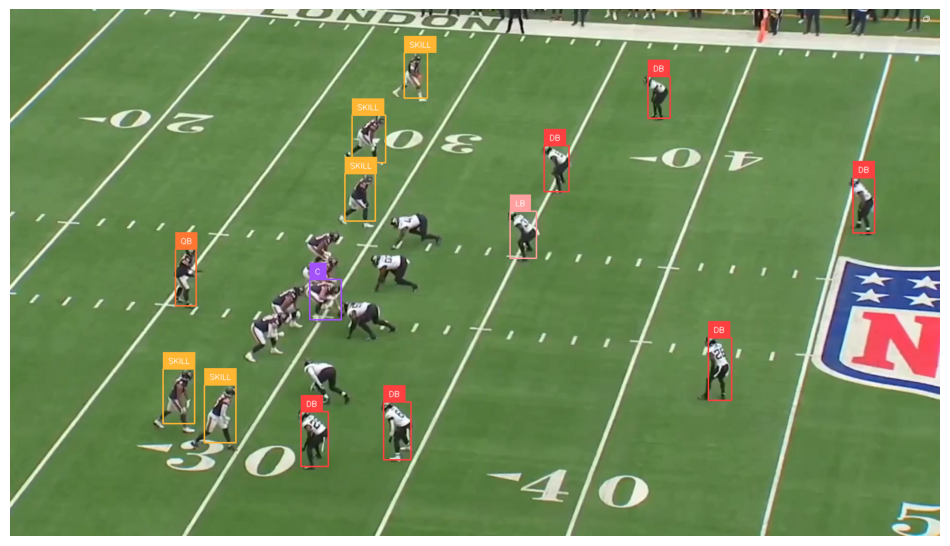

In [ ]:
os.chdir("/content/drive/MyDrive/Colab Notebooks/American Football/Resources")
image_path = "Presnap1.png"
image = cv2.imread(image_path)

# run inference on our chosen image, image can be a url, a numpy array, a PIL image, etc.
results = player_model.infer(image)[0]

# load the results into the supervision Detections api
detections = sv.Detections.from_inference(results)

# create supervision annotators
bounding_box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# annotate the image with our inference results
annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

# display the image
sv.plot_image(annotated_image)

# Keypoint Detections
Use model to detect keypoints on field for player positioning

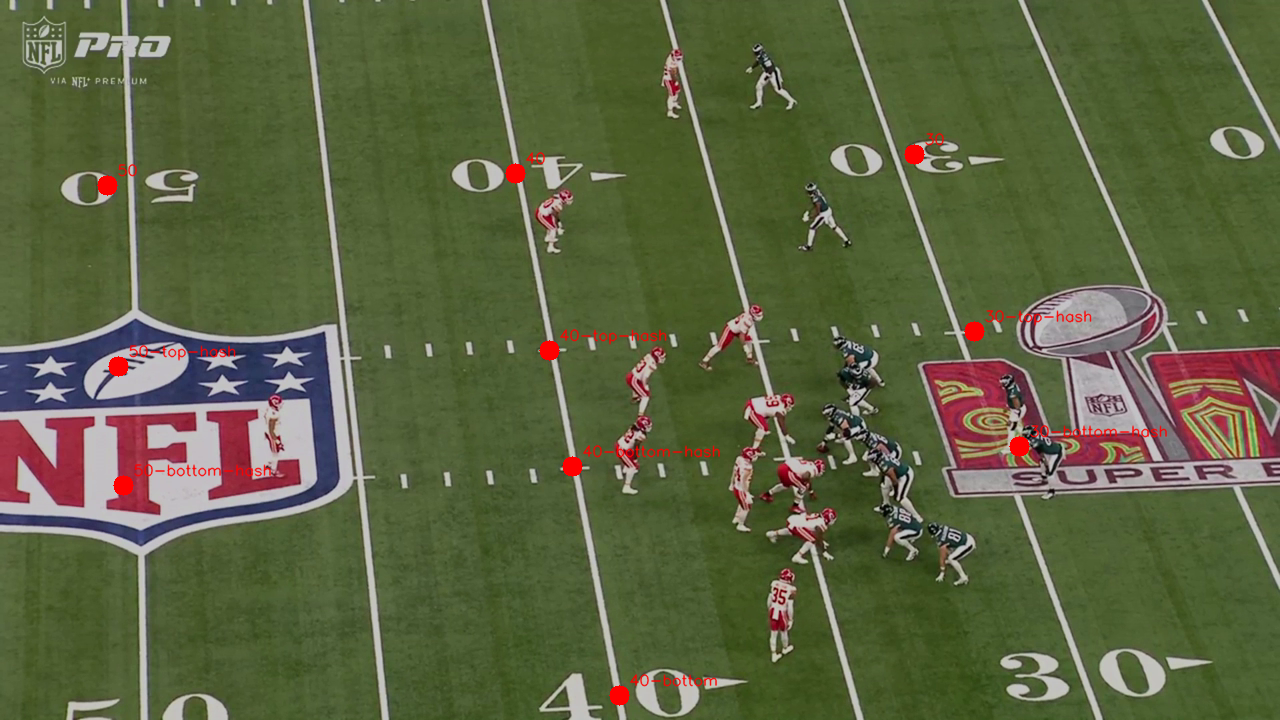

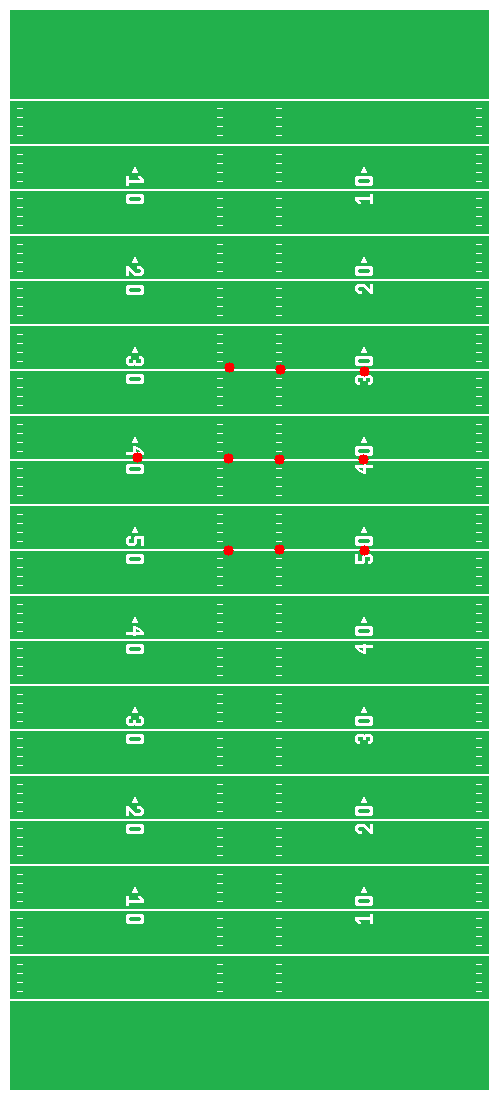

In [ ]:
os.chdir("/content/drive/MyDrive/Colab Notebooks/American Football/Resources")
field_path = "football-field.png"
field_image = cv2.imread(field_path)

video_capture = cv2.VideoCapture("videos/eagles2.mp4")
video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
_, image = video_capture.read()

results = keypoint_model.infer(image)[0]
keypoints = sv.KeyPoints.from_inference(results)

matrix, _ = getTransformationMatrix(image)

kp_locations = keypoints.xy[0]
kp_confidences = keypoints.confidence[0]

for idx, (location, confidence) in enumerate(zip(kp_locations, kp_confidences)):
    if (confidence > 0.8):
      keypoint_name = KEYPOINT_NAMES[idx]
      x, y = int(location[0]), int(location[1])
      cv2.circle(image, (x, y), 10, (0, 0, 255), -1)
      cv2.putText(image, keypoint_name, (x + 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)

      locationFloat = map_from_field(x, y, matrix)
      locationInt = (int(field_image.shape[1] - locationFloat[0]), int(locationFloat[1]))
      cv2.circle(field_image, (locationInt[0], locationInt[1]), 5, (0, 0, 255), -1)

cv2_imshow(image)
cv2_imshow(field_image)

# Player detection with tracking
Detect players initially and then track only from there. Running detections when they are not in their set formation performs very poorly

In [ ]:
# STATIC METHODS

def map_from_field(x, y, matrix):
    player_position_image = np.array([[x, y]], dtype='float32')
    player_position_map = cv2.perspectiveTransform(np.array([player_position_image]), matrix)
    return player_position_map[0][0]

def getTransformationMatrix(image):
  image_points_and_labels = getMostConfidentKeypoints(image)
  image_points = [tuple(point) for point, _ in image_points_and_labels]
  image_labels = [label for _, label in image_points_and_labels]
  map_points = [FIELD_MAP[label] for label in image_labels]

  martrix = cv2.findHomography(np.array(image_points, dtype='float32'), np.array(map_points, dtype='float32'), cv2.RANSAC)

  return martrix

def getMostConfidentKeypoints(image):
  results = keypoint_model.infer(image)[0]
  keypoints = sv.KeyPoints.from_inference(results)

  kp_locations = keypoints.xy[0]
  kp_confidences = keypoints.confidence[0]

  top_locations = [(kp_locations[idx], KEYPOINT_NAMES[idx]) for idx, confidence in enumerate(kp_confidences) if confidence > 0.5]
  return top_locations

def centerTextPosition(centerPosition, textSize):
  newX = centerPosition[0] - textSize[0] / 2
  newY = centerPosition[1] + textSize[1] / 2
  return (int(newX), int(newY))

In [ ]:
# PLAYER CLASS

class Player:
  def __init__(self, id, positionId, bbox):
    self.id = id
    self.positionId = positionId
    self.positionName = PLAYER_NAME_DICT[positionId]
    self.bbox = bbox
    self.color = PLAYER_COLOR_DICT[positionId]
    self.previousPositions = []
    self.previousFieldPositions = []

  def updateField(self, image, matrix):
    locationFloat = map_from_field(int((self.bbox[0] + self.bbox[2]) / 2), int(self.bbox[3]), matrix)
    locationInt = (int(field_image.shape[1] - locationFloat[0]), int(locationFloat[1]))
    self.previousFieldPositions.append(locationInt)

  def setTracker(self, detection):
    x1, y1, x2, y2 = detection[0]
    tracker = cv2.TrackerCSRT_create()
    tracker.init(image, (int(x1), int(y1), int(x2 - x1), int(y2 - y1)))
    self.tracker = tracker
    self.previousPositions.append(self.bbox)

  def updateTracker(self, frame):
    success, bbox = self.tracker.update(frame)
    if (success):
      x, y, w, h = [int(v) for v in bbox]
      self.bbox = (x, y, x + w, y + h)
      self.previousPositions.append(self.bbox)

  def drawSelf(self, frame, field_image):
    cv2.rectangle(frame, (self.bbox[0], self.bbox[1]), (self.bbox[2], self.bbox[3]), PLAYER_COLOR_DICT[self.positionId], 2)
    cv2.putText(frame, PLAYER_NAME_DICT[self.positionId], (self.bbox[0], self.bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, PLAYER_COLOR_DICT[self.positionId], 2)

    cv2.circle(field_image, self.previousFieldPositions[-1], 10, PLAYER_COLOR_DICT[self.positionId], -1)
    textSize = cv2.getTextSize(PLAYER_NAME_DICT[self.positionId], cv2.FONT_HERSHEY_SIMPLEX, .4, 1)[0]
    cv2.putText(field_image, PLAYER_NAME_DICT[self.positionId], centerTextPosition(self.previousFieldPositions[-1], textSize), cv2.FONT_HERSHEY_SIMPLEX, .4, (0, 0, 0), 1)


In [ ]:
# RUN DETECTIONS AND TRACKING

os.chdir("/content/drive/MyDrive/Colab Notebooks/American Football/Resources")
video_capture = cv2.VideoCapture("full-play.mp4")
field_path = "football-field.png"
field_image = cv2.imread(field_path)




_, image = video_capture.read()
video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)

results = player_model.infer(image)[0]

detections = sv.Detections.from_inference(results)

players = []
LOS = None
for idx, detection in enumerate(detections):
    player = Player(idx, detection[3], detection[0])
    player.setTracker(detection)
    players.append(player)

    if (detection[3] == C_ID):
      matrix, _ = getTransformationMatrix(image)
      LOS_y = int(map_from_field(detection[0][2], detection[0][3], matrix)[1])
      LOS = [(X_PAD, LOS_y), (FIELD_WIDTH * SCALE + X_PAD, LOS_y)]

frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
output_video = cv2.VideoWriter('tracked_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (frame_width, frame_height))
output_field = cv2.VideoWriter('field_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (FIELD_WIDTH * SCALE + 2 * X_PAD, FIELD_HEIGHT * SCALE + 2 * Y_PAD))

isPostsnap = False
total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
for frame_idx in tqdm(range(total_frames), desc="Processing frames", ncols=100):
    ret, frame = video_capture.read()
    field_image = cv2.imread(field_path)

    if not ret:
        break

    matrix, _ = getTransformationMatrix(frame)

    cv2.line(field_image, LOS[0], LOS[1], (0, 255, 255), 2)

    for player in players:
      player.updateTracker(frame)
      player.updateField(frame, matrix)
      player.drawSelf(frame, field_image)

    if (isPostsnap == False):
      isPostsnap = snap_clf_model.infer(frame)[0].top == "Postsnap"
      cv2.putText(frame, "Presnap", (0, 50), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)
      cv2.putText(field_image, "Presnap", (0, 50), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)
    else:
      cv2.putText(frame, "Postsnap", (0, 50), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)
      cv2.putText(field_image, "Postsnap", (0, 50), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)
    cv2.putText(field_image, str(frame_idx), (0, 120), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)

    output_video.write(frame)
    output_field.write(field_image)

video_capture.release()
output_video.release()
output_field.release()

Processing frames:   0%|                                                    | 0/166 [00:00<?, ?it/s]

# Full Run As JSON

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip uninstall opencv-python opencv-python-headless opencv-contrib-python -y
!pip install -q ultralytics roboflow inference supervision inference-sdk opencv-contrib-python

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
Found existing installation: opencv-python-headless 4.11.0.86
Uninstalling opencv-python-headless-4.11.0.86:
  Successfully uninstalled opencv-python-headless-4.11.0.86
Found existing installation: opencv-contrib-python 4.10.0.84
Uninstalling opencv-contrib-python-4.10.0.84:
  Successfully uninstalled opencv-contrib-python-4.10.0.84
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from inference import get_model
import supervision as sv
from google.colab.patches import cv2_imshow
from tqdm.notebook import tqdm
import numpy as np
from roboflow import Roboflow
import cv2
import json

# load a pre-trained yolov8n model
player_model = get_model(model_id="football-players-zm06l/15", api_key="KiJqNqE8Kvgwg8Ur91US")
keypoint_model = get_model(model_id="football-field-key-points/9", api_key="KiJqNqE8Kvgwg8Ur91US")
snap_clf_model = get_model(model_id="snapdetection/5", api_key="KiJqNqE8Kvgwg8Ur91US")
helmet_model = get_model(model_id="sportslocationtracking_helmets-2bdmq/2", api_key="KiJqNqE8Kvgwg8Ur91US")

Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
Specified provider 'OpenVINOExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
Specified provider 'CoreMLExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'


In [ ]:
# KEYPOINT INFORMATION

KEYPOINT_NAMES = ['goalline', 'goalline-bottom', '10', '10-top-hash',
                  '10-bottom-hash', '10-bottom', '20', '20-top-hash',
                  '20-bottom-hash', '20-bottom', '30', '30-top-hash',
                  '30-bottom-hash', '30-bottom', '40', '40-top-hash',
                  '40-bottom-hash', '40-bottom', '50', '50-top-hash',
                  '50-bottom', 'back-endzone', 'endzone-bottom',
                  '50-bottom-hash', '50-top-sl', '50-bottom-sl',
                  '40-top-sl', '40-bottom-sl', '30-top-sl', '30-bottom-sl',
                  '20-top-sl', '20-bottom-sl', '10-top-sl', '10-bottom-sl',
                  'FG-POST', '5-top-sl', '5-top-hash', '5-bottom-hash',
                  '5-bottom-sl']





# DETECTION INFORMATION

SKILL_ID = 4
LB_ID = 2
DB_ID = 1
C_ID = 0
QB_ID = 3

PLAYER_COLOR_DICT = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255),
    3: (255, 255, 0),
    4: (255, 0, 255),
}

PLAYER_NAME_DICT = {
    0: "C",
    1: "DB",
    2: "LB",
    3: "QB",
    4: "SK",
}





# FIELD LAYOUT

TOP_SL = 0
TOP_NUM = 42
TOP_HASH = 70
BOTTOM_HASH = 90
BOTTOM_NUM = 118
BOTTOM_SL = 160

FG_POST = 80
BACK_ENDZONE = 0
GOALLINE = 30
FIVE = 45
TEN = 60
TWENTY = 90
THIRTY = 120
FORTY = 150
FIFTY = 180

FIELD_WIDTH = 160
FIELD_HEIGHT = 360

FIELD_MAP = {'10-top-sl': (TOP_SL, TEN), '10': (TOP_NUM, TEN), '10-top-hash': (TOP_HASH, TEN),
            '10-bottom-hash': (BOTTOM_HASH, TEN), '10-bottom': (BOTTOM_NUM, TEN), '10-bottom-sl': (BOTTOM_SL, TEN),

            '20-top-sl': (TOP_SL, TWENTY), '20': (TOP_NUM, TWENTY), '20-top-hash': (TOP_HASH, TWENTY),
            '20-bottom-hash': (BOTTOM_HASH, TWENTY), '20-bottom': (BOTTOM_NUM, TWENTY), '20-bottom-sl': (BOTTOM_SL, TWENTY),

            '30-top-sl': (TOP_SL, THIRTY), '30': (TOP_NUM, THIRTY), '30-top-hash': (TOP_HASH, THIRTY),
            '30-bottom-hash': (BOTTOM_HASH, THIRTY), '30-bottom': (BOTTOM_NUM, THIRTY), '30-bottom-sl': (BOTTOM_SL, THIRTY),

            '40-top-sl': (TOP_SL, FORTY), '40': (TOP_NUM, FORTY), '40-top-hash': (TOP_HASH, FORTY),
            '40-bottom-hash': (BOTTOM_HASH, FORTY), '40-bottom': (BOTTOM_NUM, FORTY), '40-bottom-sl': (BOTTOM_SL, FORTY),

            '50-top-sl': (TOP_SL, FIFTY), '50': (TOP_NUM, FIFTY), '50-top-hash': (TOP_HASH, FIFTY),
            '50-bottom-hash': (BOTTOM_HASH, FIFTY), '50-bottom': (BOTTOM_NUM, FIFTY), '50-bottom-sl': (BOTTOM_SL, FIFTY),

            'goalline': (TOP_SL, GOALLINE), 'goalline-bottom': (BOTTOM_SL, GOALLINE), 'back-endzone': (TOP_SL, BACK_ENDZONE), 'endzone-bottom': (BOTTOM_SL, BACK_ENDZONE),
            'FG-POST': (FG_POST, BACK_ENDZONE), '5-top-sl': (TOP_SL, FIVE), '5-top-hash': (TOP_HASH, FIVE), '5-bottom-hash': (BOTTOM_HASH, FIVE), '5-bottom-sl': (BOTTOM_SL, FIVE)}

In [ ]:
# STATIC METHODS

def map_from_field(x, y, matrix):
    player_position_image = np.array([[x, y]], dtype='float32')
    player_position_map = cv2.perspectiveTransform(np.array([player_position_image]), matrix)
    return player_position_map[0][0]

def getTransformationMatrix(image):
  image_points_and_labels = getMostConfidentKeypoints(image)
  image_points = [tuple(point) for point, _ in image_points_and_labels]
  image_labels = [label for _, label in image_points_and_labels]
  map_points = [FIELD_MAP[label] for label in image_labels]

  return cv2.findHomography(np.array(image_points, dtype='float32'), np.array(map_points, dtype='float32'), cv2.RANSAC)

def getMostConfidentKeypoints(image):
  results = keypoint_model.infer(image)[0]
  keypoints = sv.KeyPoints.from_inference(results)

  kp_locations = keypoints.xy[0]
  kp_confidences = keypoints.confidence[0]

  top_locations = [(kp_locations[idx], KEYPOINT_NAMES[idx]) for idx, confidence in enumerate(kp_confidences) if confidence > 0.5]
  return top_locations

def centerTextPosition(centerPosition, textSize):
  newX = centerPosition[0] - textSize[0] / 2
  newY = centerPosition[1] + textSize[1] / 2
  return (int(newX), int(newY))

In [ ]:
# PLAYER CLASS

class Player:
  def __init__(self, id, positionId, bbox):
    self.id = id
    self.positionId = positionId
    self.positionName = PLAYER_NAME_DICT[positionId]
    self.bbox = bbox
    self.previousPositions = []
    self.previousFieldPositions = []

  def to_dict(self):
    return {
        'positionId': self.positionId,
        'positionName': self.positionName,
        'previousFieldPositions': self.previousFieldPositions
    }

  def updateField(self, image, matrix):
    locationFloat = map_from_field(int((self.bbox[0] + self.bbox[2]) / 2), int(self.bbox[3]), matrix)
    locationInt = (int(FIELD_WIDTH - locationFloat[0]), int(locationFloat[1]))
    self.previousFieldPositions.append(locationInt)

  def setTracker(self, detection):
    x1, y1, x2, y2 = detection[0]
    tracker = cv2.TrackerCSRT_create()
    tracker.init(image, (int(x1), int(y1), int(x2 - x1), int(y2 - y1)))
    self.tracker = tracker
    self.previousPositions.append(self.bbox)

  def updateTracker(self, frame):
    success, bbox = self.tracker.update(frame)
    if (success):
      x, y, w, h = [int(v) for v in bbox]
      self.bbox = (x, y, x + w, y + h)
      self.previousPositions.append(self.bbox)

class PlayerEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.int64):
            return int(obj)
        if isinstance(obj, Player):
            return obj.to_dict()
        return super().default(obj)

In [ ]:
# RUN DETECTIONS AND TRACKING

os.chdir("/content/drive/MyDrive/Colab Notebooks/American Football/Resources")
video_capture = cv2.VideoCapture("full-play.mp4")

_, image = video_capture.read()
video_capture.set(cv2.CAP_PROP_POS_FRAMES, 0)

results = player_model.infer(image)[0]

detections = sv.Detections.from_inference(results)

players = []
LOSy = None
for idx, detection in enumerate(detections):
    player = Player(idx, detection[3], detection[0])
    player.setTracker(detection)
    players.append(player)

    if (detection[3] == C_ID):
      matrix, _ = getTransformationMatrix(image)
      LOSy = int(map_from_field(detection[0][2], detection[0][3], matrix)[1])

isPostsnap = False
total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
for frame_idx in tqdm(range(total_frames), desc="Processing frames", ncols=100):
    ret, frame = video_capture.read()

    if not ret:
        break

    matrix, _ = getTransformationMatrix(frame)

    for player in players:
      player.updateTracker(frame)
      player.updateField(frame, matrix)

json_data = {
    'LOSy': LOSy,
    'players': players
}

with open('players.json', 'w') as json_file:
    json.dump(json_data, json_file, indent=4, cls=PlayerEncoder)

Processing frames:   0%|                                                    | 0/166 [00:00<?, ?it/s]

# YOLO Helmet tracking

In [ ]:
os.chdir("/content/drive/MyDrive/Colab Notebooks/American Football/Resources")
video_capture = cv2.VideoCapture("full-play.mp4")

detections = sv.Detections.from_inference(results)
